# ICH Texture Analysis and Generation

See [Issue 143 on characterizing ICH texture](https://github.com/DIDSR/InSilicoICH/issues/143)

This may be worth putting into a dedicated repo as it will likely be its own paper

## Characterize ICH Texture in Real-World Data

Datasets:
1. [Hssayeni](https://physionet.org/content/ct-ich/)
2. [INSTANCE](https://instance.grand-challenge.org/)
3. [BHSD](https://huggingface.co/datasets/Wendy-Fly/BHSD)
4. [CQ500](https://paperswithcode.com/dataset/cq500)

See `.env` file for path locations

Next update these functions and clean them up so I can easily run this feature analysis (shape [volume, sphericity], first order features [mean], and texture features [glcm contrast, glcm correlation]) for all datasets including synthetic and use this as a platform the updat eht esynthetic data

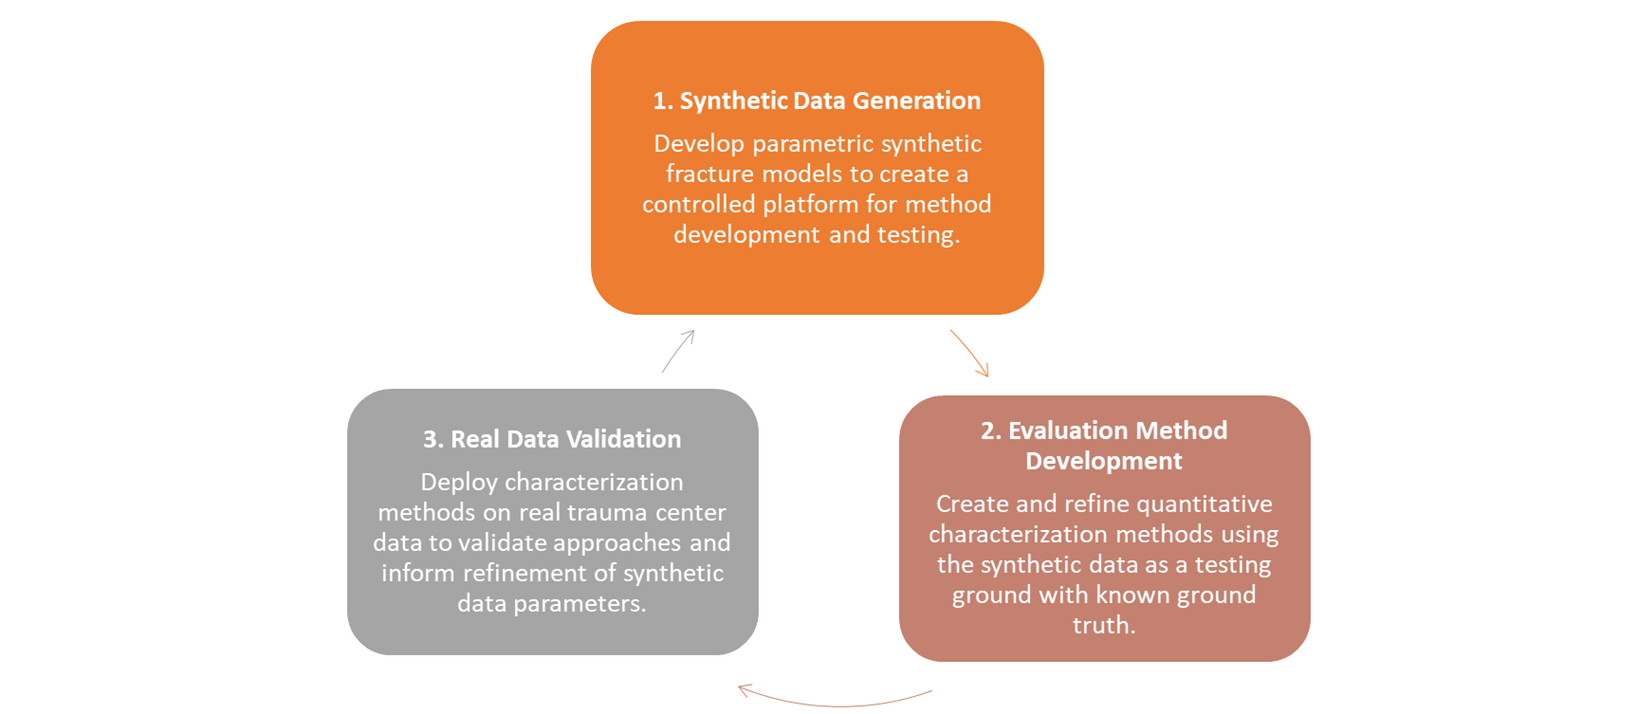

Note: this is the 2nd iteration of this loop, previously we just did volume and mean for the [first paper](https://zenodo.org/records/15750437).

## Hssayeni

Use [Pyradiomics](https://github.com/AIM-Harvard/pyradiomics) to get first order, shape, and texture features:

The goal is to measure these features on the real datasets and synthetic then iterate the synthetic data parameters to get the radiomics features to match (can do this manually or iteratively)

In [1]:
from pathlib import Path
import os

from dotenv import load_dotenv
import pandas as pd
from skimage.measure import label

from plot import visualize_ich_projections, visualize_ich_slices
from measures import HssayeniLoader

load_dotenv()

HSSAYENI_PATH = Path(os.environ.get('HSSAYENI_DIRECTORY'))
hssayeni_loader = HssayeniLoader(dataset_path=HSSAYENI_PATH)
ids = hssayeni_loader.get_patient_ids()
print(ids)

[49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130]


In [2]:
hssayeni_loader.target_spacing

(1.0, 1.0, 1.0)

--- Global Maximum Intensity Projections ---


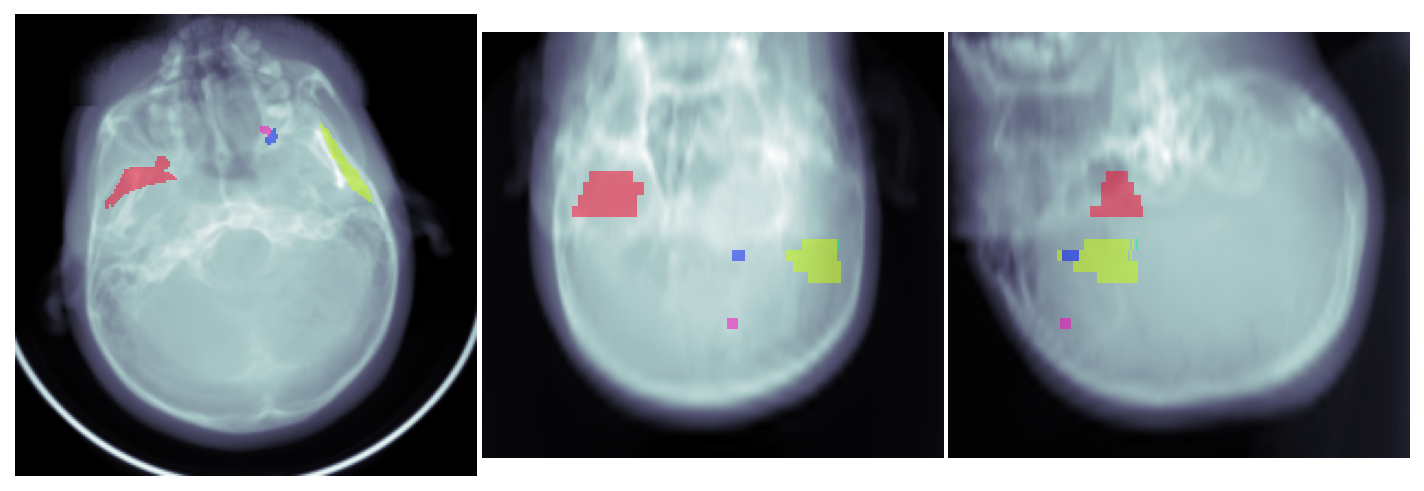


--- Individual Hemorrhage Cross-Sectional Views ---


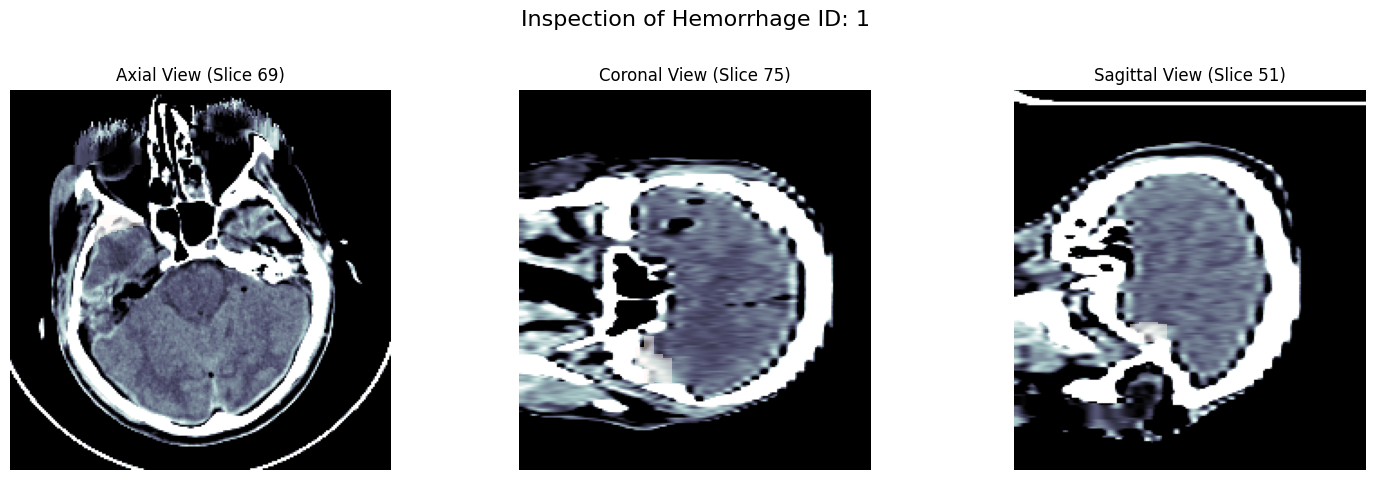

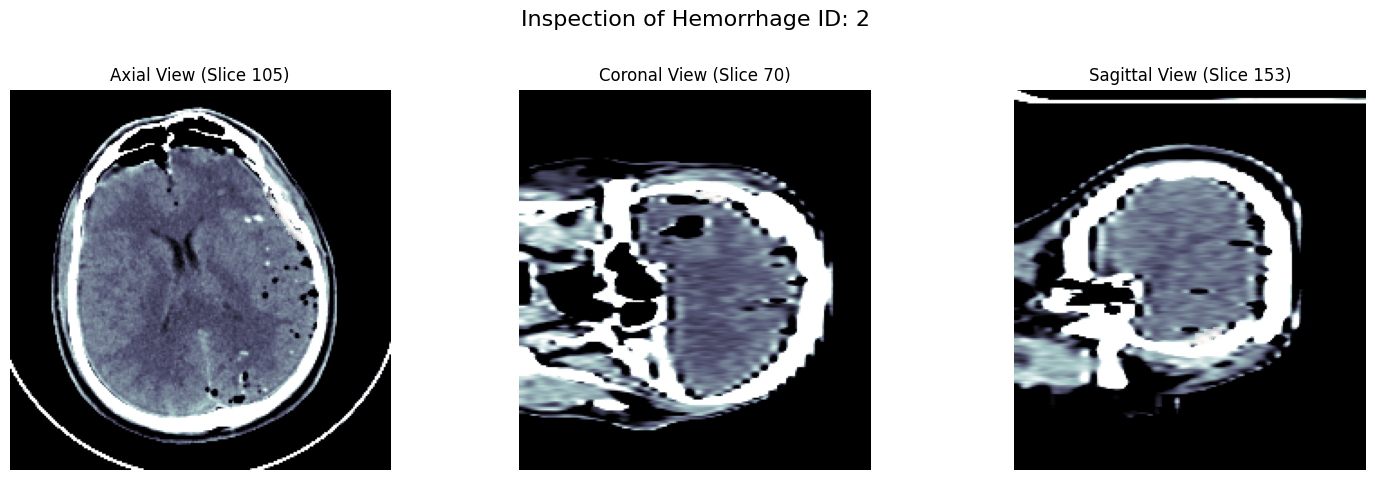

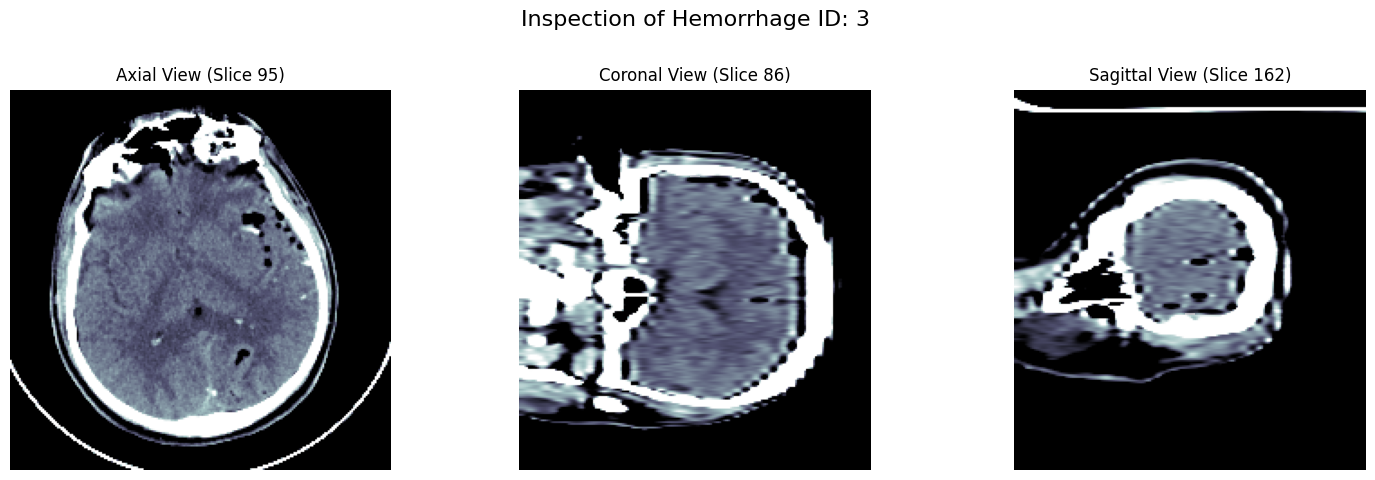

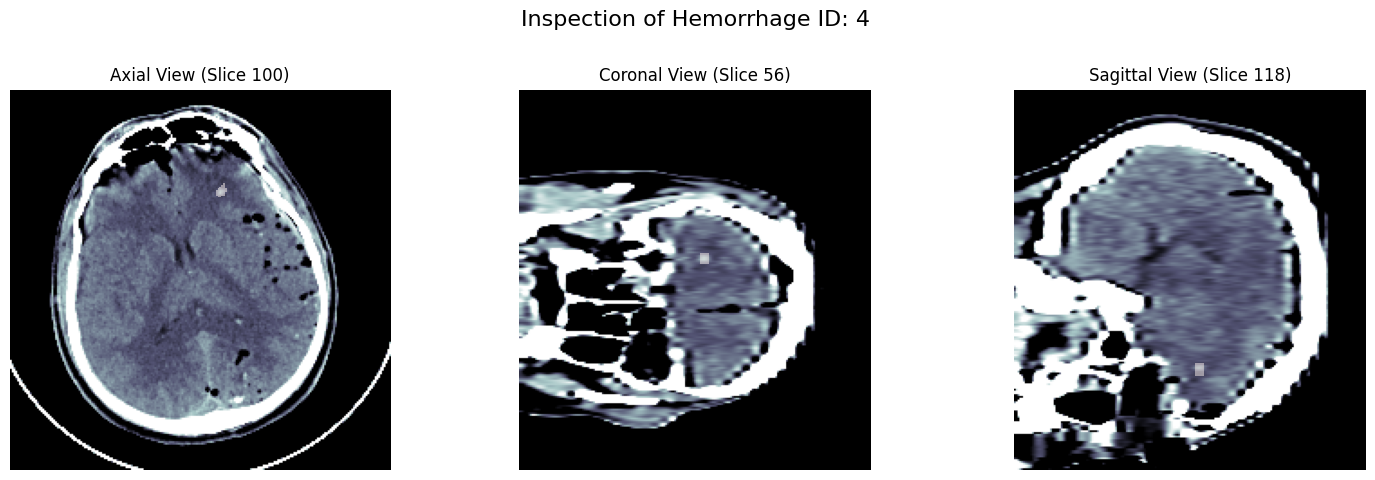

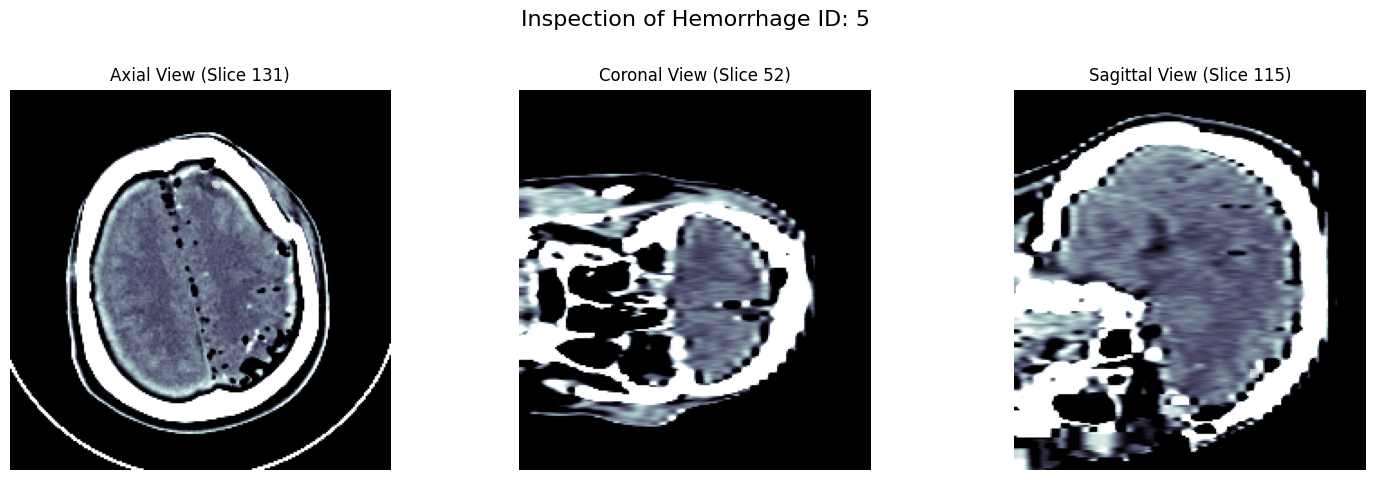

In [3]:
img, mask, _ = hssayeni_loader.load_patient_data(49)
mask = label(mask)
visualize_ich_projections(img, mask)
visualize_ich_slices(img, mask)

In [4]:
from measures import RadiomicsFeatureExtractor
import numpy as np

lesion_mask = np.zeros_like(mask).astype(bool)
lesion_mask[mask] = True
feature_extractor = RadiomicsFeatureExtractor()
feature_extractor.extract_features_for_lesion(img, lesion_mask)

{'sphericity': np.float64(0.25743061733218314),
 'compactness': np.float64(0.01706006154141184),
 'contrast': np.float64(22.614965213234395),
 'correlation': np.float64(0.41024895956850765),
 'energy': np.float64(0.5699556508948093),
 'homogeneity': np.float64(0.6553321623191999),
 'mean_attenuation': np.float64(48.37697931790633),
 'std_attenuation': np.float64(30.762032707654026),
 'volume_voxel': np.int64(64514)}

In [5]:
from measures import run_feature_extraction_pipeline

combined_csv = Path('combined_radiomics_features.csv')
if combined_csv.exists():
    combined = pd.read_csv(combined_csv)
    hssayeni = combined[combined['dataset'] == 'Hssayeni']
else:
    hssayeni = run_feature_extraction_pipeline(hssayeni_loader)
hssayeni

Processing HssayeniLoader:   0%|          | 0/82 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
hssayeni.corr(numeric_only=True)

In [ ]:
hssayeni.describe()

In [ ]:
hssayeni.pop('compactness')
hssayeni.pop('lesion_index')
hssayeni.pop('ID')

In [ ]:
import seaborn as sns
# sns.pairplot(data=hssayeni, hue='subtype')

## BHSD

Run the same pipeline through BHSD and the other datasets and the synthetic one

In [ ]:
from measures import BHSDLoader
bhsd_directory = Path(os.environ.get('BHSD_DIRECTORY'))
bhsd_loader = BHSDLoader(dataset_path=bhsd_directory)
ids = bhsd_loader.get_patient_ids()

In [ ]:
img, mask, _ = bhsd_loader.load_patient_data(ids[0])
mask = label(mask)
visualize_ich_projections(img, mask)
visualize_ich_slices(img, mask)

In [ ]:
if combined_csv.exists():
    bhsd = combined[combined['dataset'] == 'BHSD']
else:
    bhsd = run_feature_extraction_pipeline(bhsd_loader)
bhsd

In [ ]:
bhsd.pop('compactness')
bhsd.pop('lesion_index')
bhsd.pop('ID')

In [ ]:
# sns.pairplot(data=bhsd[bhsd['volume_ml']>0.5], hue='subtype')

In [ ]:
bhsd.corr(numeric_only=True)

## Instance

from measures import InstanceLoader
# INSTANCE_PATH = Path(os.environ.get('INSTANCE_DIRECTORY'))
loader = InstanceLoader(INSTANCE_PATH)
img, mask, _ = loader.load_patient_data(6)
# mask = label(mask)
visualize_ich_projections(img, mask)
visualize_ich_slices(img, mask)

## Make Synthetic ICH

In [6]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [7]:
phantom = available_phantoms['6.5 yr NIHPD Head']()
phantom

pseudo-CT images not found; defaulting to otsu segmentation method



        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 0

In [8]:
from insilicoICH.study import ICHStudy
import pandas as pd

single_study = ICHStudy.generate_from_distributions(
    ['6.5 yr NIHPD Head'],
    study_count=1,
    scanner_model=['Siemens_DefinitionFlash'],
    subtype=['IPH'],
    output_directory = 'texture_scale_characteristics',
    texture_contrast=[0.9, 1.1],
    texture_scale=[39, 40],
    seed=42)
single_study

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity,age,mass_effect,fracture_length,add_augmentation
0,case_0000,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,39.094177,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True


In [15]:
scales = np.linspace(40, 0, 10, dtype=int)
scales

array([40, 35, 31, 26, 22, 17, 13,  8,  4,  0])

In [19]:
study_list = [single_study]
nrepeats = 2
for idx, scale in enumerate(scales[1:]):
    for _ in range(nrepeats):
        temp = single_study.copy()
        temp['texture_scale'] = scale
        temp['case_id'] = f'case_{idx+1:04d}'
        temp['output_directory'] = single_study.output_directory.item().parent / f'case_{idx+1:04d}'
        study_list.append(temp)
study_list = pd.concat(study_list, ignore_index=True)
study = ICHStudy(study_list)
study.metadata

,case_id,phantom,scanner_model,kVp,mA,pitch,views,scan_coverage,recon_kernel,slice_thickness,...,texture_contrast,texture_scale,complexity,smoothness,irregularity,eccentricity,age,mass_effect,fracture_length,add_augmentation
0,case_0000,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,39.094177,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
1,case_0001,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,35.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
2,case_0001,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,35.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
3,case_0002,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,31.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
4,case_0002,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,31.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
5,case_0003,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,26.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
6,case_0003,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,26.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
7,case_0004,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,22.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
8,case_0004,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,22.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True
9,case_0005,6.5 yr NIHPD Head,Siemens_DefinitionFlash,120.0,300.0,0.0,1000.0,dynamic,soft,1,...,1.039474,17.000000,3,0.392687,0.328342,0.714426,6.5,0.202491,0,True


In [ ]:
study.run_all(parallel=True)

study plan saved to: /scratch/brandon.nelson/InSilicoICH/notebooks/texture_scale_characteristics/texture_scale_characteristics_study_plan.csv
Running 19 simulation conditions
See logs at /scratch/brandon.nelson/InSilicoICH/notebooks/texture_scale_characteristics/logs/VIT-BATCH_07-24-2025_13-37
9066399


Scans completed in parallel:   0%|          | 0/19 [00:00<?, ?it/s]

Key textures:
1. scale --> glcm_contrast
2. contrast_std --> std_attenuation

In [ ]:
scales

In [ ]:
from measures import SyntheticLoader

loader = SyntheticLoader(phantoms)
img, mask, _ = loader.load_patient_data(-3)
mask = label(mask)
visualize_ich_projections(img, mask)
visualize_ich_slices(img, mask)

In [ ]:
len(loader.phantoms)

In [ ]:
lesion_mask = np.zeros_like(mask).astype(bool)
lesion_mask[mask == 1] = True
feature_extractor = RadiomicsFeatureExtractor()
feature_extractor.extract_features_for_lesion(img, lesion_mask)

In [ ]:
synth = run_feature_extraction_pipeline(loader)
synth

In [ ]:
scale_dict = {k: v for k, v in zip(seeds, scales)}
synth['scale'] = synth['ID'].apply(lambda o: scale_dict[o]).astype(float)
synth

In [ ]:
sns.scatterplot(data=synth, x='scale', y='contrast')

## Next

Make a for loop to generate a list of ~10 patients each with a different perlin noise scale factor and then each patient will have 10 synthetich IPH with that same scale factor, this will make it easier to quantify because the patient ID can be the scale factor for easier correlation analysis

In [ ]:
sns.pairplot(data=synth)

In [ ]:
combined = pd.read_csv('combined_radiomics_features.csv')
combined = pd.concat([combined, synth], ignore_index=True)
combined

In [ ]:
# combined = pd.read_csv('combined_radiomics_features.csv')
combined.pop('lesion_index')
combined.pop('volume_voxel')
combined.pop('compactness')
combined.pop('energy')

In [ ]:
sns.pairplot(data=combined, hue='subtype')

In [ ]:
sns.pairplot(data=combined, hue='dataset')

In [ ]:
combined.groupby('dataset').describe()['contrast']

In [ ]:
combined.groupby('dataset').describe()['correlation']

In [ ]:
combined.groupby(['subtype', 'dataset']).describe()['sphericity']

In [ ]:
f, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=combined, x='subtype', y='sphericity', hue='dataset', ax=ax)

In [ ]:
f, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=combined, x='subtype', y='volume_ml', hue='dataset', ax=ax)

In [ ]:
f, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=combined, x='subtype', y='mean_attenuation', hue='dataset', ax=ax)

In [ ]:
f, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=combined, x='subtype', y='std_attenuation', hue='dataset', ax=ax)

## See if features differ dramatically across datasets

In [ ]:
# sns.pairplot(data=combined, hue='dataset')

looks like they're all pretty consistent across datasets

In [ ]:
# sns.pairplot(data=combined[combined['dataset'] != 'Hssayeni'], hue='subtype')

In [ ]:
import matplotlib.pyplot as plt
def visualize_center_slice(image_vol, mask, title=""):
    """Plots the central slice of the 3D image and mask."""
    center_z = image_vol.shape[0] // 2
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(title, fontsize=14)
    
    # Plot Image
    ax[0].imshow(image_vol[center_z], cmap='gray', vmin=0, vmax=200)
    ax[0].set_title("Image Texture")
    ax[0].axis('off')
    
    # Plot Mask Overlay
    ax[1].imshow(image_vol[center_z], cmap='gray', vmin=0, vmax=200)
    ax[1].imshow(np.ma.masked_where(~mask[center_z], mask[center_z]), cmap='spring', alpha=0.5)
    ax[1].set_title("Mask Shape")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

def run_demonstration(title, image_vol, mask, feature_extractor):
    """Helper function to run extraction, print results, and visualize."""
    print(f"\n--- {title} ---")
    features = feature_extractor.extract_features_for_lesion(image_vol, mask)
    
    print(f"Sphericity: {features.get('sphericity', 'N/A'):.4f}")
    print(f"GLCM Contrast: {features.get('contrast', 'N/A'):.4f}")
    print(f"GLCM Correlation: {features.get('correlation', 'N/A'):.4f}")
    
    visualize_center_slice(image_vol, mask, title)


if __name__ == '__main__':
    # Initialize the feature extractor
    extractor = RadiomicsFeatureExtractor()
    
    # Define a standard 3D volume size for our examples
    D, H, W = 64, 64, 64
    
    # --- Example 1: High Sphericity ---
    # A perfect sphere has the highest possible sphericity (~1.0).
    # Texture does not affect shape features.
    img_vol_sphere = np.full((D, H, W), 1, dtype=np.uint8)
    z, y, x = np.ogrid[-D//2:D//2, -H//2:H//2, -W//2:W//2]
    mask_sphere = x*x + y*y + z*z <= (D//4)**2
    img_vol_sphere[mask_sphere] = 100
    run_demonstration("High Sphericity (Perfect Sphere)", img_vol_sphere, mask_sphere, extractor)

    # --- Example 2: Low Sphericity ---
    # An elongated, non-compact shape has low sphericity.
    img_vol_ellipsoid = np.full((D, H, W), 1, dtype=np.uint8)
    mask_ellipsoid = (x/2)**2 + (y/8)**2 + (z/2)**2 <= (D//16)**2
    img_vol_ellipsoid[mask_ellipsoid] = 100
    run_demonstration("Low Sphericity (Elongated Ellipsoid)", img_vol_ellipsoid, mask_ellipsoid, extractor)

    # --- Example 3: Low GLCM Contrast ---
    # Contrast is low when neighboring voxels are very similar (homogeneous texture).
    # We use a sphere mask and fill it with a near-constant intensity.
    img_vol_low_contrast = np.full((D, H, W), 1, dtype=np.uint8) # Background
    img_vol_low_contrast[mask_sphere] = 100
    run_demonstration("Low GLCM Contrast (Homogeneous Texture)", img_vol_low_contrast, mask_sphere, extractor)

    # --- Example 4: High GLCM Contrast ---
    # Contrast is high when neighboring voxels are very different (heterogeneous texture).
    # We create a "salt and pepper" texture by alternating between two very different values.
    img_vol_high_contrast = np.full((D, H, W), 1, dtype=np.uint8)
    lesion_texture = np.random.choice([50, 150], size=mask_sphere.sum())
    img_vol_high_contrast[mask_sphere] = lesion_texture
    run_demonstration("High GLCM Contrast (Salt & Pepper Texture)", img_vol_high_contrast, mask_sphere, extractor)

    # --- Example 5: High GLCM Correlation ---
    # Correlation is high when there is a predictable, linear pattern in the texture.
    # We create a smooth gradient texture across the x-axis.
    img_vol_high_corr = np.full((D, H, W), 1, dtype=np.uint8)
    gradient = np.linspace(50, 150, W, dtype=np.uint8)
    lesion_texture = np.tile(gradient, (D, H, 1))
    img_vol_high_corr[mask_sphere] = lesion_texture[mask_sphere]
    run_demonstration("High GLCM Correlation (Gradient Texture)", img_vol_high_corr, mask_sphere, extractor)

    # --- Example 6: Low GLCM Correlation ---
    # Correlation is low when the texture is random and unpredictable.
    # We fill the lesion with uniform random noise. This also creates high contrast.
    img_vol_low_corr = np.full((D, H, W), 1, dtype=np.uint8)
    lesion_texture = np.random.randint(50, 150, size=mask_sphere.shape, dtype=np.uint8)
    img_vol_low_corr[mask_sphere] = lesion_texture[mask_sphere]
    run_demonstration("Low GLCM Correlation (Random Noise Texture)", img_vol_low_corr, mask_sphere, extractor)
